In [1]:
import pandas as pd
import numpy as np


import cudf
import dask_cudf   # xử lý dataframe lớn trên GPU

    Vì dữ liệu rất lớn, khoảng 67,5 triệu row, số lượng khách hàng sẽ ít hơn 67,5 triệu nhưng vẫn có thể lên tới hàng triệu , vì vậy ta sẽ sử dụng cudf và dask_cudf để load data trên GPU

In [2]:
# Load toàn bộ CSV trong thư mục Kaggle trên GPU
cdf = dask_cudf.read_csv(
    "/kaggle/input/ecommerce-behavior-data-from-multi-category-store/*.csv",
    dtype={
        'event_time':'str',
        'user_session':'str',
        'category_id':'str',
        'category_code':'str', # meaning full , ex: "furniture.bedroom.bed"
        'user_id':'int',
        'product_id':'int',
        'event_type':'str',
        'brand':'str',
        'price':'float32'
    }
)

# Các cột ta giữ lại sẽ là "event_type","product_id",'category_code', "brand", "price","user_id"
cdf = cdf[["event_type","product_id",'category_code', "brand", "price","user_id"]]  
cdf.head()


,event_type,product_id,category_code,brand,price,user_id
0,view,1003461,electronics.smartphone,xiaomi,489.070007,520088904
1,view,5000088,appliances.sewing_machine,janome,293.649994,530496790
2,view,17302664,<NA>,creed,28.309999,561587266
3,view,3601530,appliances.kitchen.washer,lg,712.869995,518085591
4,view,1004775,electronics.smartphone,xiaomi,183.270004,558856683


Chuyển dask_cudf sang cudf, vì 1 số thao tác để tránh tràn memory trên GPU

In [3]:
df = cdf.compute()

Thống NA value trên các cột

In [4]:

NULL = df.isnull().sum().to_frame().to_pandas()
NULL.columns = ['null counts']
NULL['ratio'] = NULL.iloc[:,:]/df.shape[0]
NULL.apply(lambda s: s.apply('{0:.2f}'.format))

,null counts,ratio
event_type,0.00,0.00
product_id,0.00,0.00
category_code,35413780.00,0.32
brand,15341158.00,0.14
price,0.00,0.00
user_id,0.00,0.00


Ta có thể thấy chỉ có cột category_code, brand có row NA. Vì vậy ta sẽ fill 'unknown' cho các row này thay vì drop chúng vì các row này vẫn còn các thông tin khác.

In [5]:
df['category_code'] = df['category_code'].fillna('unknown')
df['brand'] = df['brand'].fillna('unknown')

In [6]:
df.head()

,event_type,product_id,category_code,brand,price,user_id
0,view,1003461,electronics.smartphone,xiaomi,489.070007,520088904
1,view,5000088,appliances.sewing_machine,janome,293.649994,530496790
2,view,17302664,unknown,creed,28.309999,561587266
3,view,3601530,appliances.kitchen.washer,lg,712.869995,518085591
4,view,1004775,electronics.smartphone,xiaomi,183.270004,558856683


Ta sẽ thống kê số lượng event trên từng user

In [7]:
event_pivot = df.pivot_table(
    index=['user_id'],
    columns=['event_type'],
    values=['product_id'], 
    aggfunc='count'
)
event_pivot = event_pivot.fillna(0)

event_pivot.columns = event_pivot.columns.get_level_values(-1)

event_pivot.head()


event_type,cart,purchase,view
user_id,,,
10300217,0,0,1
29515875,0,0,11
31198833,0,0,20
33869381,0,0,1
34916060,0,0,1


Ta sẽ thống kê số sản phẩm khác nhau, số hãng khác nhau, tổng số tiền đã tiêu, số tiền trung bình trên 1 sản phẩm của từng khách hàng

In [8]:
user_features = df.groupby('user_id').agg({
    'product_id': 'nunique',
    'category_code': 'nunique',
    'brand': 'nunique',
    'price': ['sum', 'mean']
})

user_features.columns = [
    'unique_products',
    'unique_categories',
    'unique_brands',
    'total_price',
    'avg_price'
]

user_features.head()

,unique_products,unique_categories,unique_brands,total_price,avg_price
user_id,,,,,
10300217,1,1,1,40.540001,40.540001
29515875,5,2,5,3026.729736,275.157249
31198833,18,3,5,6426.179688,321.308984
33869381,1,1,1,769.649963,769.649963
34916060,1,1,1,295.940002,295.940002


Merge 2 bảng ta vừa tạo để tạo df_user, đây sẽ bảng chứa các feature để ta phân cụm

In [9]:
df_user = user_features.merge(event_pivot, left_index=True, right_index=True, how='left')

df_user.head()

,unique_products,unique_categories,unique_brands,total_price,avg_price,cart,purchase,view
user_id,,,,,,,,
452237734,4,2,3,285.779968,40.825710,0,0,7
452242088,1,1,1,3.710000,3.710000,0,0,1
452246450,4,2,2,1633.839966,408.459991,0,0,4
452246868,1,1,1,202.939987,202.939987,0,0,1
452248565,5,1,2,1271.430054,181.632865,0,0,7


Thêm 2 feature là view_to_cart_rate và cart_to_purchase_rate 

In [10]:
df_user['view_to_cart_rate'] = df_user['cart'] / (df_user['view'] + 1)
df_user['cart_to_purchase_rate'] = df_user['purchase'] / (df_user['cart'] + 1)

df_user.head()

,unique_products,unique_categories,unique_brands,total_price,avg_price,cart,purchase,view,view_to_cart_rate,cart_to_purchase_rate
user_id,,,,,,,,,,
452237734,4,2,3,285.779968,40.825710,0,0,7,0.0,0.0
452242088,1,1,1,3.710000,3.710000,0,0,1,0.0,0.0
452246450,4,2,2,1633.839966,408.459991,0,0,4,0.0,0.0
452246868,1,1,1,202.939987,202.939987,0,0,1,0.0,0.0
452248565,5,1,2,1271.430054,181.632865,0,0,7,0.0,0.0


Ta sẽ thêm 1 feature cuối cùng để đo xem user hay xem/mua các sản phẩm phổ biến hay ít phổ biến.

Việc tạo feature này lại cần làm trên dask_cudf để tránh OOM

In [11]:
cdf['category_code'] = cdf['category_code'].fillna('unknown')
cdf['brand'] = cdf['brand'].fillna('unknown')

In [ ]:
cat_count = cdf['category_code'].value_counts().compute()

def map_cat_freq_partition(df, cat_count_series):
    df['cat_freq'] = df['category_code'].map(cat_count_series)
    return df

cdf = cdf.map_partitions(map_cat_freq_partition, cat_count) 
cat_pref = cdf.groupby('user_id')['cat_freq'].mean().compute().rename("category_popularity")  
cat_pref.head()
df_user = df_user.merge(cat_pref.reset_index(), on='user_id', how='left')


In [13]:
df_user.head()

,unique_products,unique_categories,unique_brands,total_price,avg_price,cart,purchase,view,view_to_cart_rate,cart_to_purchase_rate,user_id,category_popularity
0,1,1,1,5.120000,5.120000,0,0,1,0.000000,0.0,453028690,3.541378e+07
1,1,1,1,94.980003,94.980003,0,0,1,0.000000,0.0,453029046,2.650791e+06
2,3,3,3,499.079987,166.359996,0,0,3,0.000000,0.0,453033136,1.198987e+07
3,3,2,2,1000.640015,142.948574,2,0,5,0.333333,0.0,453037918,1.220372e+07
4,3,1,2,138.240005,46.080002,0,0,3,0.000000,0.0,453038499,3.541378e+07


Trước khi áp dụng phân cụm, ta cần chuẩn hóa các cột feature

In [ ]:
from cuml.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_user)

In [15]:
X_scaled.head()

,0,1,2,3,4,5,6,7,8,9,10,11
0,-0.416828,-0.551254,-0.509252,-0.339397,-0.968135,-0.241097,-0.174618,-0.357698,-0.242326,-0.262259,-4.157622,1.172167
1,-0.416828,-0.551254,-0.509252,-0.334336,-0.682962,-0.241097,-0.174618,-0.357698,-0.242326,-0.262259,-4.157607,-1.467418
2,-0.330014,0.275176,-0.235481,-0.311576,-0.456436,-0.241097,-0.174618,-0.319286,-0.242326,-0.262259,-4.157426,-0.715005
3,-0.330014,-0.138039,-0.372367,-0.283327,-0.530733,0.407037,-0.174618,-0.280874,2.170777,-0.262259,-4.157215,-0.697776
4,-0.330014,-0.551254,-0.372367,-0.331899,-0.838148,-0.241097,-0.174618,-0.319286,-0.242326,-0.262259,-4.157190,1.172167


In [ ]:
X_scaled.shape[1]

12

Mục tiêu của ta là phân  người dùng ra 20 cụm. Áp dụng phân cụm cho ~ 5.5 triệu người dùng là rất lớn. Ta cần 1 phương pháp phân cụm để tránh bị OOM. Ta có 1 thuật có tên là Scalable K-Means++ gồm các bước:
- Chia dữ liệu thành các vùng nhỏ (proto-clusters) phản ánh mật độ thật của dataset
- Sampling có phân tầng theo proto (giữ phân phối gốc, giảm số lượng điểm)
- Thực hiện KMeans trên sample
- Gán cluster trên toàn bộ dataset bằng nearest centroid (1-NN)

 Vì số cluster là 200 nên sẽ tránh OOM hơn, max_iter=50 cũng giới hạn thời gian thực thi nhưng vẫn đảm bảo 200 proto cluster phản ánh mật độ thật của dataset

In [17]:
from cuml.cluster import KMeans

km_proto = KMeans(
    n_clusters=200,
    init="k-means||",
    oversampling_factor=2,
    max_iter=50
)
km_proto.fit(X_scaled)
df_user['proto'] = km_proto.labels_


/usr/local/lib/python3.11/dist-packages/cuml/internals/api_decorators.py:195: FutureWarning: The default value of `n_init` will change from 1 to 'auto' in 25.04. Set the value of `n_init` explicitly to suppress this warning.
  return func(*args, **kwargs)


Sampling mẫu theo các proto cluster

In [18]:
frac = 150000 / len(df_user)
df_sample = df_user.groupby("proto").sample(frac=frac)
df_sample = df_sample.drop(columns=["proto"])

In [19]:
X_scaled_sampled = scaler.fit_transform(df_sample)

In [20]:
X_scaled_sampled.head()

,0,1,2,3,4,5,6,7,8,9,10,11
0,-0.379246,-0.552662,-0.511126,-0.271275,-0.121921,0.090391,-0.189968,-0.321048,1.264644,-0.264880,1.313718,0.564544
1,-0.335133,-0.552662,-0.511126,-0.273705,-0.148449,0.090391,-0.189968,-0.321048,1.264644,-0.264880,0.282728,0.564544
2,-0.335133,-0.552662,-0.236691,-0.160084,0.053565,0.779498,-0.189968,-0.259101,2.592487,-0.264880,1.060364,0.564544
3,-0.423358,-0.552662,-0.511126,-0.323382,-0.494754,0.090391,-0.189968,-0.362345,2.276334,-0.264880,1.396091,0.564544
4,-0.423358,-0.552662,-0.511126,-0.326525,-0.551950,0.090391,0.424267,-0.382994,3.540946,1.246554,1.313783,-1.496503


Áp dụng Kmean cho tập sampled. Do tập sample chỉ 150K user nên rất nhanh

In [21]:
km_final = KMeans(n_clusters=20, init="k-means||")
km_final.fit(X_scaled_sampled)


/usr/local/lib/python3.11/dist-packages/cuml/internals/api_decorators.py:195: FutureWarning: The default value of `n_init` will change from 1 to 'auto' in 25.04. Set the value of `n_init` explicitly to suppress this warning.
  return func(*args, **kwargs)


KMeans()

150k user sampled đã làm nhiệm vụ đại diện cho toàn bộ phân phối của data. Bây giờ ta chỉ cần áp 1-NN để gán các user còn lại

In [22]:
from cuml.neighbors import NearestNeighbors
import cupy as cp

centers = km_final.cluster_centers_


nn = NearestNeighbors(n_neighbors=1)
nn.fit(centers)

distances, indices = nn.kneighbors(X_scaled)


df_user['cluster'] = cp.asnumpy(indices).flatten()

In [23]:
df_user.head()

,unique_products,unique_categories,unique_brands,total_price,avg_price,cart,purchase,view,view_to_cart_rate,cart_to_purchase_rate,user_id,category_popularity,proto,cluster
0,1,1,1,5.120000,5.120000,0,0,1,0.000000,0.0,453028690,3.541378e+07,98,1
1,1,1,1,94.980003,94.980003,0,0,1,0.000000,0.0,453029046,2.650791e+06,98,1
2,3,3,3,499.079987,166.359996,0,0,3,0.000000,0.0,453033136,1.198987e+07,98,1
3,3,2,2,1000.640015,142.948574,2,0,5,0.333333,0.0,453037918,1.220372e+07,98,1
4,3,1,2,138.240005,46.080002,0,0,3,0.000000,0.0,453038499,3.541378e+07,98,1


Ta đã thực hiện xong việc gán nhãn cluster cho từng user. Tiếp đến ta sẽ đi sau vào ý nghĩa của từng cụm hay phân tích sâu ý nghĩa các cụm khách hàng,

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

In [32]:
df_user["cluster"].value_counts()

cluster
15    2556214
1     1263140
18     648245
10     242353
9      197522
2      166922
19      90743
3       46932
13      42929
16      14757
11      12966
0       10984
6        9294
7        9206
12       1624
4         977
5         765
14        597
8         338
17        141
Name: count, dtype: int64

Đếm số user trên từng cụm

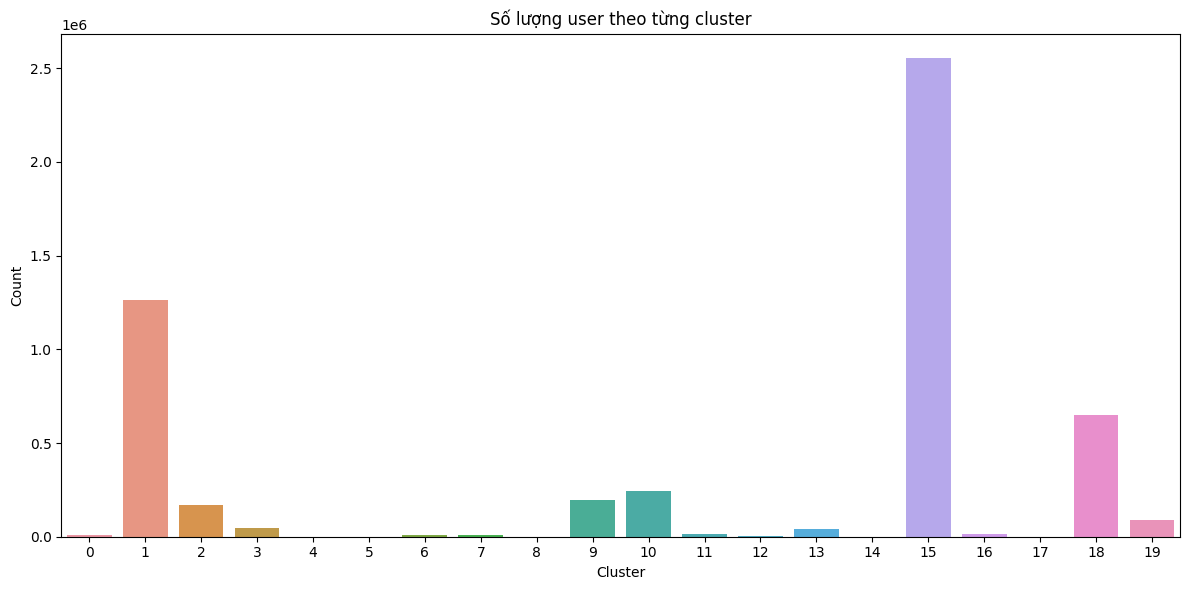

In [31]:
cluster_counts = df_user["cluster"].value_counts().sort_index().to_pandas()

plt.figure(figsize=(12,6))
sns.barplot(x=cluster_counts.index, y=cluster_counts.values)

plt.xlabel("Cluster")
plt.ylabel("Count")
plt.title("Số lượng user theo từng cluster")
plt.tight_layout()
plt.show()

Tổng hợp toàn bộ thông tin trung bình từng khách hàng của từng cụm

In [25]:
cluster_summary = df_user.groupby("cluster", sort=True).agg({
    "unique_products": "mean",
    "unique_categories": "mean",
    "unique_brands": "mean",
    "total_price": "mean",
    "avg_price": "mean",
    "view": "mean",
    "cart": "mean",
    "purchase": "mean",
    "view_to_cart_rate": "mean",
    "cart_to_purchase_rate": "mean",
    "category_popularity": "mean"
}).round(2)
print(cluster_summary)

         unique_products  unique_categories  unique_brands  total_price  \
cluster                                                                   
0                  66.46               7.84          22.54     54484.91   
1                   4.72               1.61           2.61      2606.91   
2                  12.34               2.73           5.82      6883.56   
3                 128.40              13.11          42.77     57205.23   
4                  51.66               5.84          16.68     29131.27   
5                   2.35               1.33           1.60     10718.49   
6                 265.69              17.71          66.36    175480.12   
7                  46.04               6.39          15.77     54957.27   
8                 112.65              10.09          29.62    269033.82   
9                  54.20               8.14          22.10     22347.99   
10                  3.68               1.54           2.19      3522.54   
11                 28.45 

Ta sẽ vẽ lên biểu đồ radar, qua đó biết được xu hướng của từng cụm

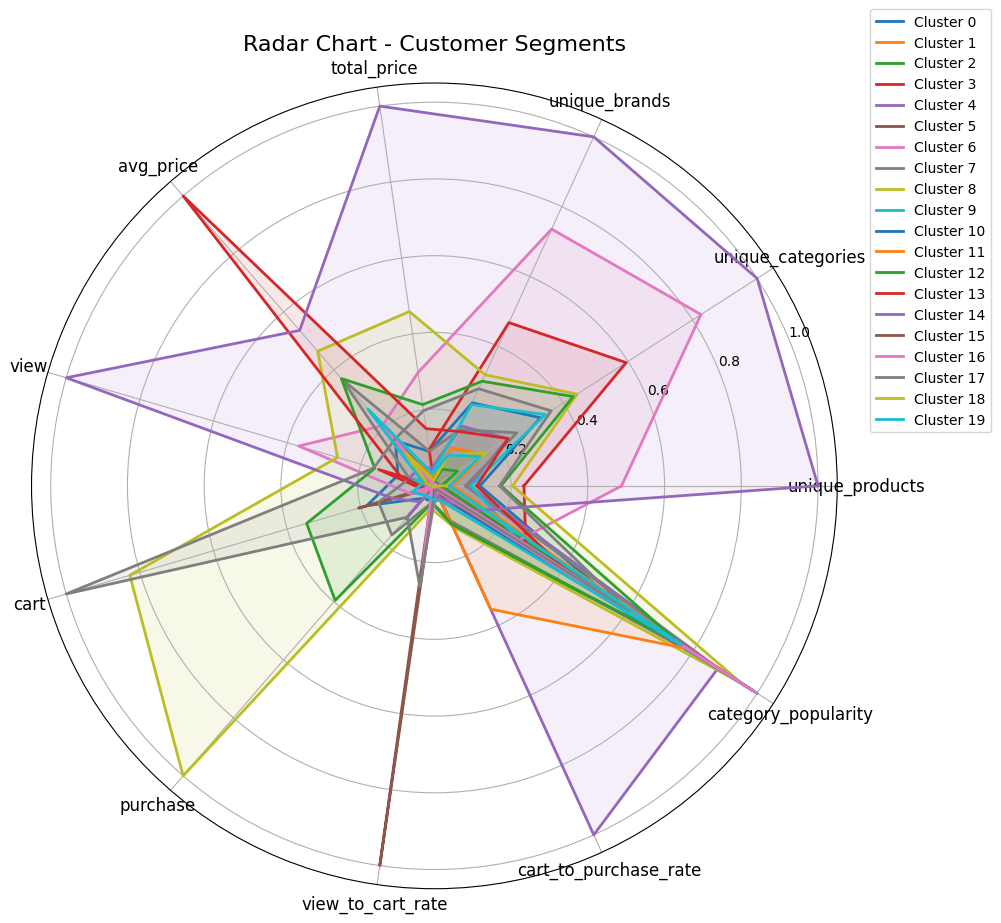

In [ ]:
from sklearn.preprocessing import MinMaxScaler

cluster_summary_pd = cluster_summary.to_pandas()

scaler = MinMaxScaler()
cluster_summary_norm = pd.DataFrame(
    scaler.fit_transform(cluster_summary_pd),
    columns=cluster_summary_pd.columns,
    index=cluster_summary_pd.index
)

df_radar = cluster_summary_norm.copy()
categories = df_radar.columns.tolist()
N = len(categories)

angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]   
plt.figure(figsize=(10, 10))

for idx, row in df_radar.iterrows():
    values = row.tolist()
    values += values[:1]

    plt.polar(angles, values, linewidth=2, label=f"Cluster {idx}")
    plt.fill(angles, values, alpha=0.1)

plt.xticks(angles[:-1], categories, fontsize=12)
plt.title("Radar Chart - Customer Segments", fontsize=16)
plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1))
plt.tight_layout()

plt.show()

Tiếp đến ta sẽ thống kê các mặt hàng, nhãn hàng mà các cụm tương tác nhiều nhất

In [42]:
df_user = df_user.set_index('user_id')

merged = cdf.merge(
    df_user[['cluster']],
    left_on='user_id',
    right_index=True
)

counts = merged.groupby(['cluster', 'category_code']).size().compute()
counts = counts.rename("count").reset_index()


In [43]:
counts.head()

,cluster,category_code,count
0,3,electronics.camera.video,11458
1,8,country_yard.furniture.hammok,1
2,7,furniture.bedroom.bed,6742
3,3,kids.fmcg.diapers,7912
4,11,appliances.kitchen.washer,16172


Đếm số lượng tương tác của các cluster, hiển thị 3 mặt hàng có só tương tác nhiều nhất (bỏ qua unknown)

In [ ]:
top3_cat = (
    counts[counts['category_code'] != 'unknown']                # bỏ unknown
          .sort_values(['cluster', 'count'], ascending=[True, False])
          .groupby('cluster', group_keys=False)
          .head(3)
)

print(top3_cat)

      cluster                category_code    count
11          0       electronics.smartphone   633871
611         0         electronics.video.tv    78281
892         0  electronics.audio.headphone    70515
1506        1       electronics.smartphone  3398499
676         1  electronics.audio.headphone   267428
2007        1           electronics.clocks   257841
2162        2       electronics.smartphone  1150393
662         2           electronics.clocks   132269
47          2  electronics.audio.headphone   122345
1298        3       electronics.smartphone  1501083
1416        3                apparel.shoes   447758
2451        3           electronics.clocks   396229
1546        4       electronics.smartphone    16117
1365        4                apparel.shoes     3823
1607        4           electronics.clocks     2735
1257        5       electronics.smartphone    15996
209         5    appliances.kitchen.washer     1113
1138        5  electronics.audio.headphone     1015
288         

Qua biểu đồ ta có thể xác định nhóm khách hàng tiềm năng cho mặt hàng cụ thệ

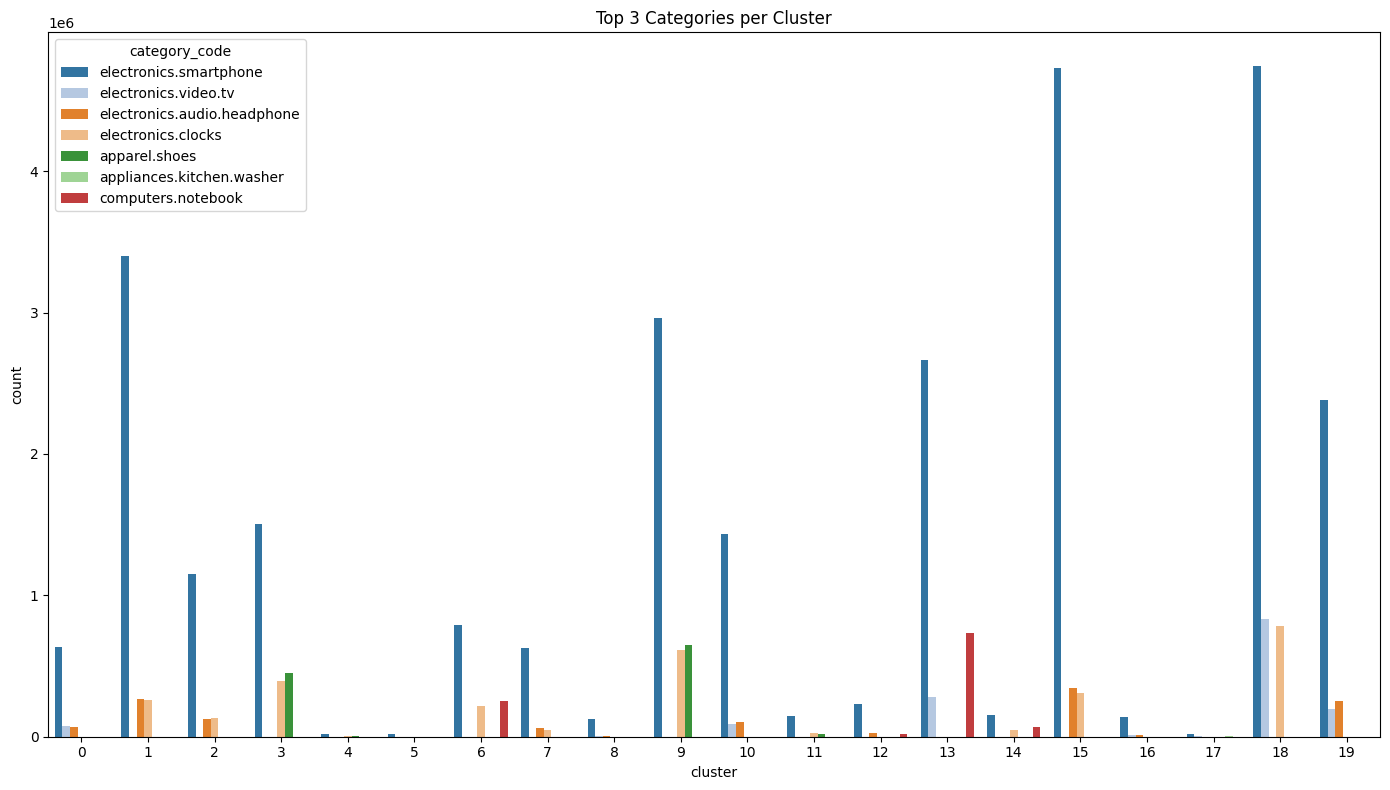

In [49]:
plt.figure(figsize=(14, 8))
sns.barplot(
    data=top3_cat.to_pandas(),
    x="cluster",
    y="count",
    hue="category_code",
    palette="tab20"
)

plt.title("Top 3 Categories per Cluster")
plt.tight_layout()
plt.show()

Ta làm tương tự với nhãn hàng (brand)

In [ ]:
merged = cdf.merge(df_user[['cluster']], left_on='user_id', right_index=True)
counts_brand = merged.groupby(['cluster', 'brand']).size().compute().rename('count').reset_index()

top3_brands = (
    counts_brand[counts_brand['brand'] != 'unknown'] 
                  .sort_values(['cluster', 'count'], ascending=[True, False])
                  .groupby('cluster', group_keys=False)
                  .apply(lambda x: x.head(3))
)
print(top3_brands)

       cluster    brand    count
37083        0  samsung   299589
57213        0    apple   236362
7656         0   xiaomi   191313
23414        1    apple  1467865
10346        1  samsung  1454408
31595        1   xiaomi   728131
54363        2  samsung   544551
20651        2    apple   442212
36836        2   xiaomi   291128
30175        3  samsung   776969
46237        3   xiaomi   662556
40467        3    apple   372275
44591        4  lucente     7415
18800        4    apple     6735
50026        4  samsung     6223
56492        5  samsung    10880
16155        5    apple     4200
11321        5   xiaomi     2152
49340        6  samsung   343537
54415        6   xiaomi   321588
15342        6    apple   235144
13367        7    apple   308848
20625        7  samsung   286554
25600        7   xiaomi    97745
285          8  samsung    67070
814          8    apple    57749
14529        8   xiaomi    11643
6489         9  samsung  1638651
19428        9   xiaomi  1165963
15098     

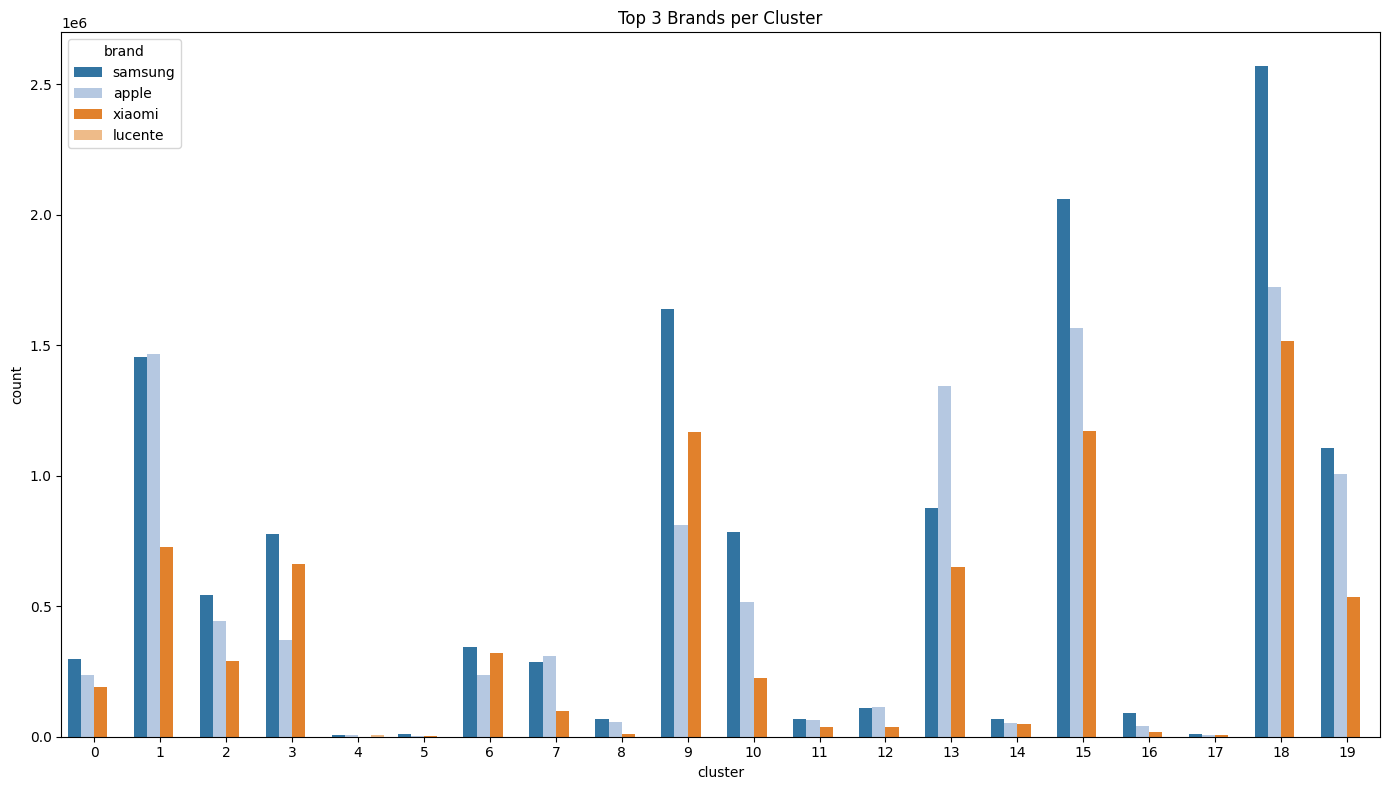

In [51]:
plt.figure(figsize=(14, 8))
sns.barplot(
    data=top3_brands.to_pandas(),
    x="cluster",
    y="count",
    hue="brand",
    palette="tab20"
)

plt.title("Top 3 Brands per Cluster")
plt.tight_layout()
plt.show()

Tiếp đến ta sẽ gán nhãn hành vi cho từng user, các nhãn bao gồm:
- Người chỉ xem sản phẩm (browser): view > 0, cart = 0 và purchase = 0
- Khách hàng bỏ giỏ (cart_abandoner): cart > 0, purchase = 0
- Khách có mua hàng (converter): purchase > 0
- khách hàng trung thành: purchase > 2, cart_to_purchase_rate > 0.5
- Còn lại

In [52]:
df_user['behavior_type'] = 'other'
df_user.loc[(df_user['view'] > 0) & (df_user['cart'] == 0) & (df_user['purchase'] == 0), 'behavior_type'] = 'browser'
df_user.loc[(df_user['cart'] > 0) & (df_user['purchase'] == 0), 'behavior_type'] = 'cart_abandoner'
df_user.loc[df_user['purchase'] > 0, 'behavior_type'] = 'converter'
df_user.loc[(df_user['purchase'] > 2) & (df_user['cart_to_purchase_rate'] > 0.5), 'behavior_type'] = 'loyalist'

# Phân bố behavior_type theo cụm
behavior_by_cluster = (
    df_user.groupby(['cluster', 'behavior_type'])
           .size()                  
           .reset_index(name='count')  
           .pivot(index='cluster', columns='behavior_type', values='count')
           .fillna(0)
)

print(behavior_by_cluster)

behavior_type  browser  cart_abandoner  converter  loyalist
cluster                                                    
0                    0            1576       8864       544
1              1152120           77314      33706         0
2                    0               0     140717     26205
3                 7676           11851      21901      5504
4                    0               0          0       977
5                    0             378        387         0
6                  769            2021       5014      1490
7                    0               0        923      8283
8                    0               0         19       319
9                74543           53841      62922      6216
10                   0           93036     139994      9323
11                   0               0          0     12966
12                   0               0        192      1432
13               10797           14937      15179      2016
14                  63             116  

Qua biểu đồ ta có thể xác định được các hành vi của từng cụm.

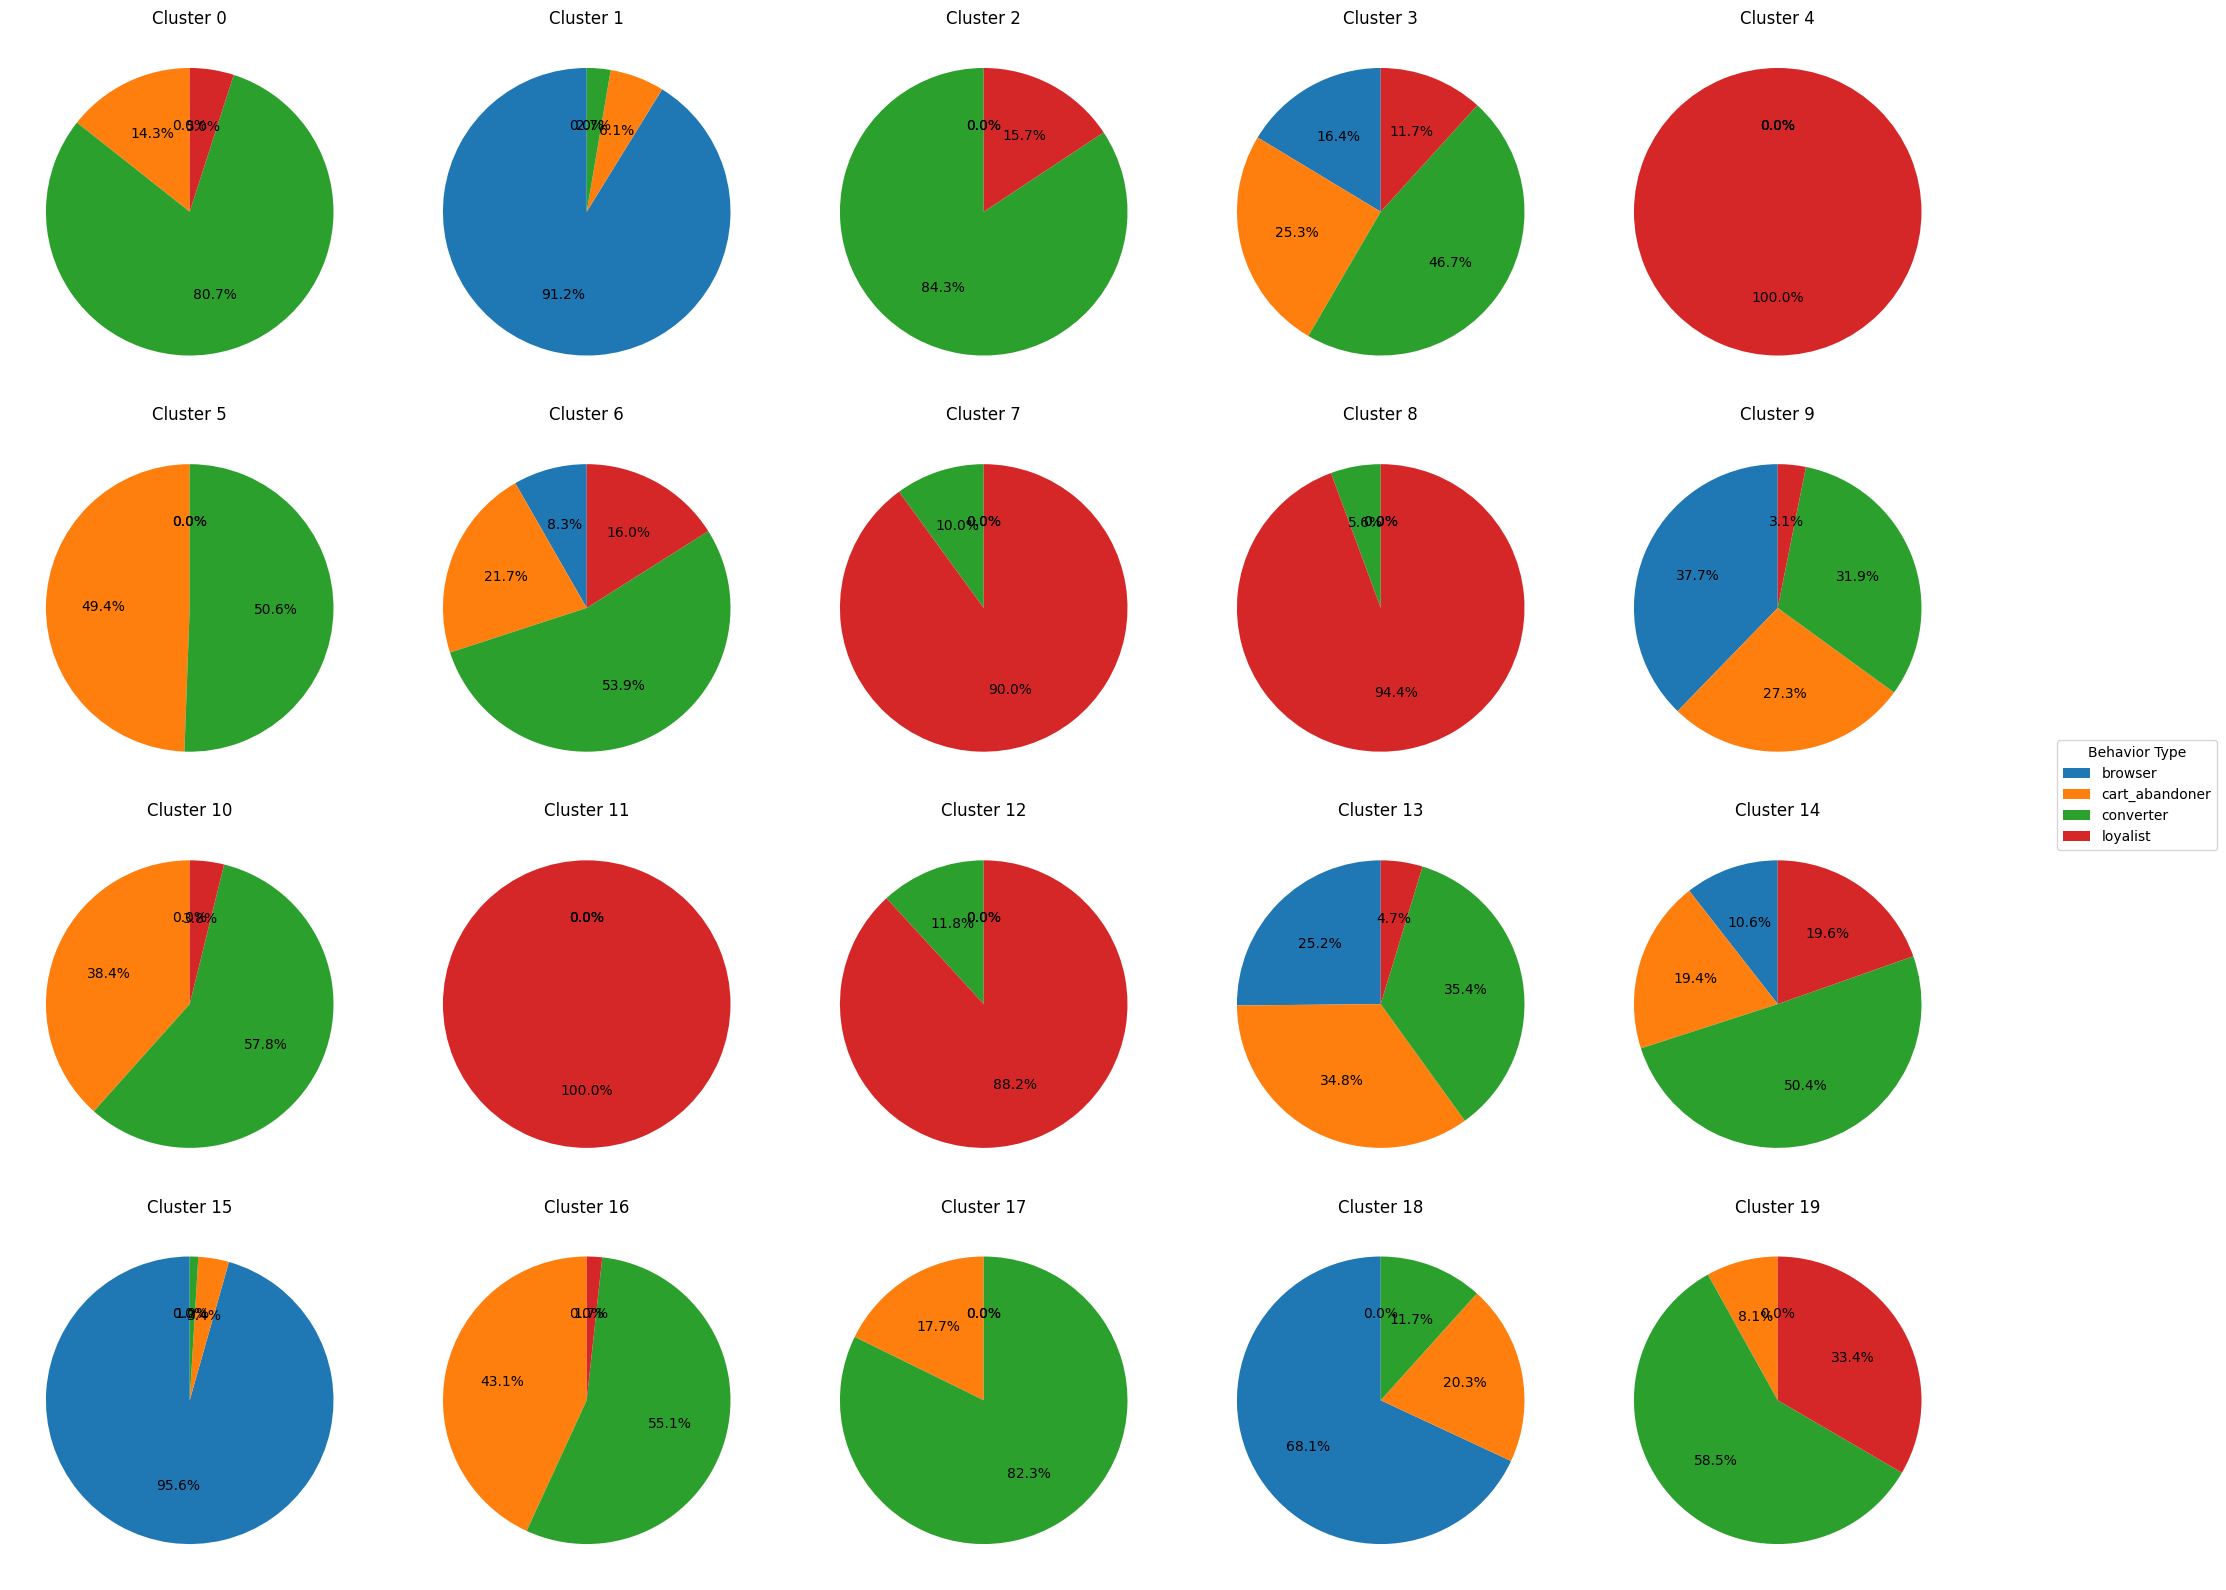

In [ ]:
behavior_by_cluster_pd = behavior_by_cluster.to_pandas()

clusters = behavior_by_cluster_pd.index
cols = behavior_by_cluster_pd.columns

fig, axes = plt.subplots(4, 5, figsize=(20, 16))
axes = axes.flatten()

#  legend
legend_patches = None

for i, cluster in enumerate(clusters):
    ax = axes[i]
    values = behavior_by_cluster_pd.loc[cluster]

    wedges, texts, autotexts = ax.pie(
        values,
        labels=None,       
        autopct="%1.1f%%",
        startangle=90
    )

    ax.set_title(f"Cluster {cluster}")

    if legend_patches is None:
        legend_patches = wedges

for j in range(len(clusters), len(axes)):
    axes[j].axis("off")

fig.legend(
    legend_patches,
    cols,
    title="Behavior Type",
    loc="center right",
    bbox_to_anchor=(1.12, 0.5)
)

plt.tight_layout()
plt.show()
